In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_curve, roc_auc_score,
                             classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries Imported!")

✅ Libraries Imported!


In [3]:
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df = pd.read_csv(url)
print("✅ Dataset Loaded!")
print(df.shape)
print(df.head())

✅ Dataset Loaded!
(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [4]:
print("\n--- Missing Values ---")
print(df.isnull().sum())

df.dropna(inplace=True)
print(f"\n✅ Missing Values After Handling: {df.isnull().sum().sum()}")
print(df.describe())



--- Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

✅ Missing Values After Handling: 0
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

 

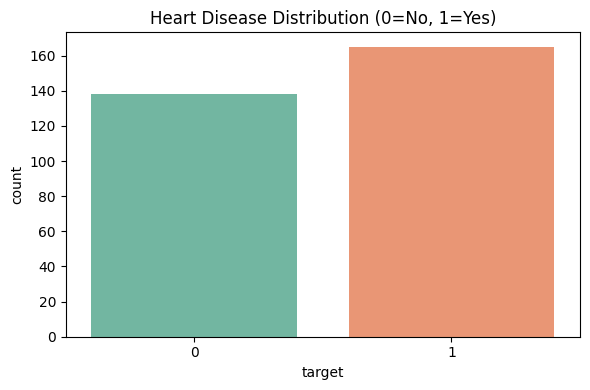

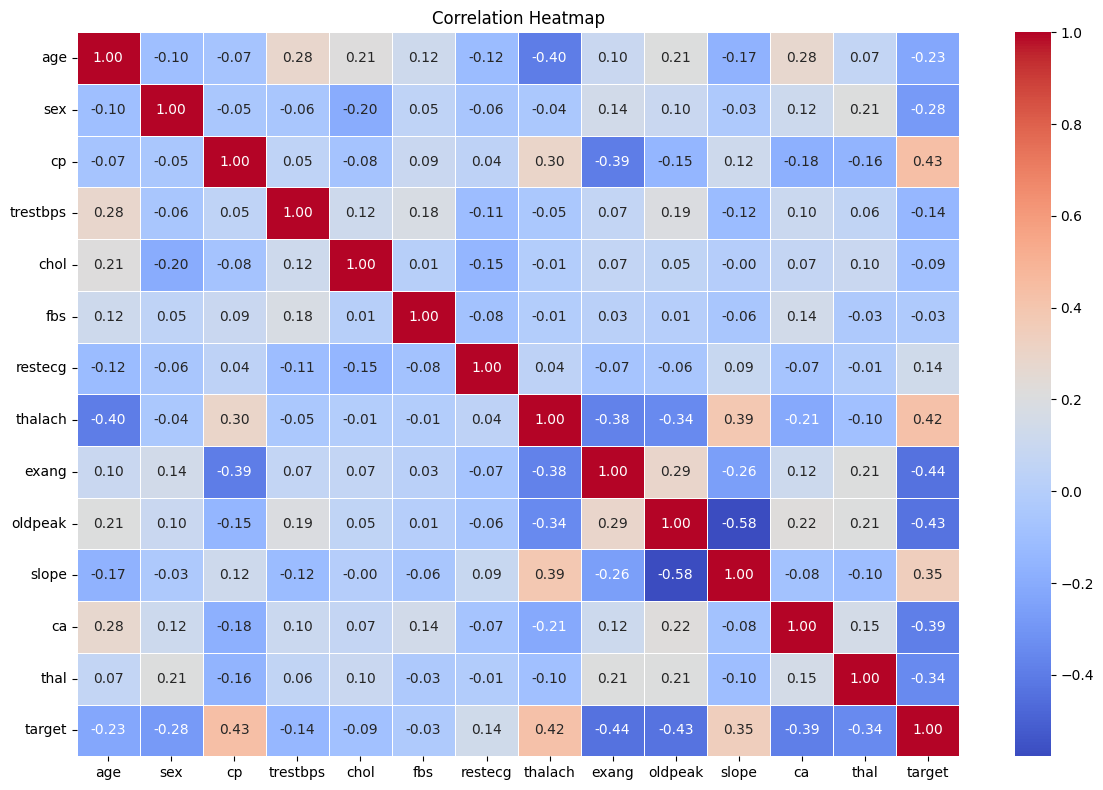

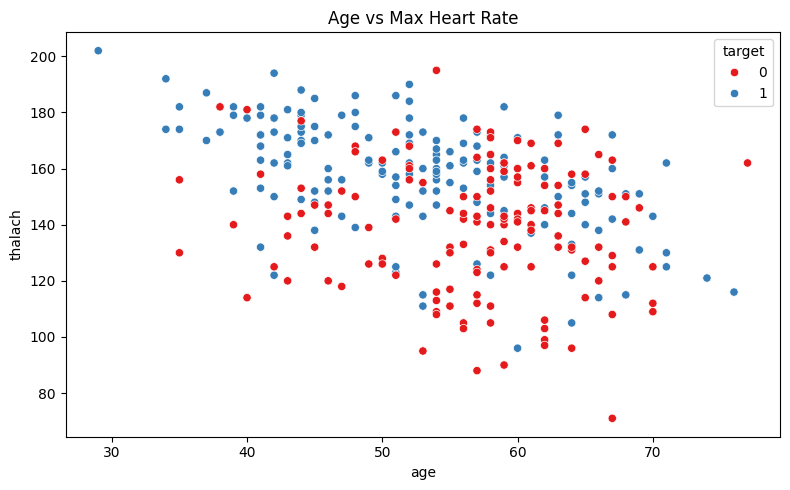

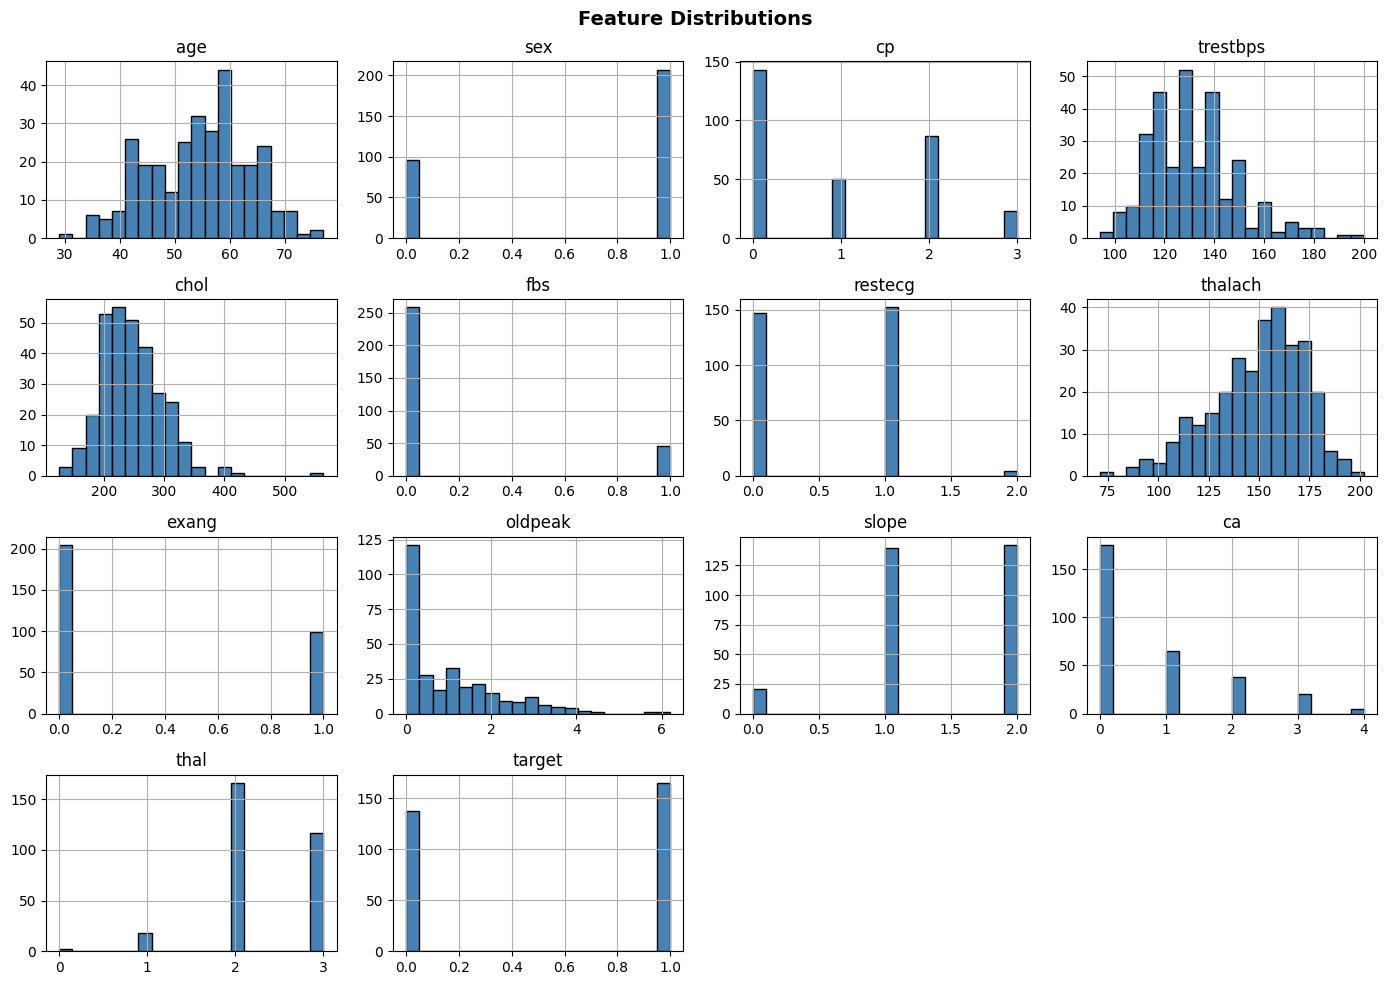

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Distribution (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Age vs Max Heart Rate
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='Set1')
plt.title('Age vs Max Heart Rate')
plt.tight_layout()
plt.show()
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\n✅ Train: {X_train.shape} | Test: {X_test.shape}")


✅ Train: (242, 13) | Test: (61, 13)


In [7]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

print("✅ Models Trained!")

✅ Models Trained!


In [8]:
def evaluate(name, y_test, y_pred, y_prob):
    print(f"\n📊 {name}")
    print(f"   Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"   ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"\n{classification_report(y_test, y_pred)}")

evaluate("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate("Decision Tree",       y_test, dt_pred, dt_prob)


📊 Logistic Regression
   Accuracy : 0.8525
   ROC-AUC  : 0.9267

              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61


📊 Decision Tree
   Accuracy : 0.7541
   ROC-AUC  : 0.7592

              precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



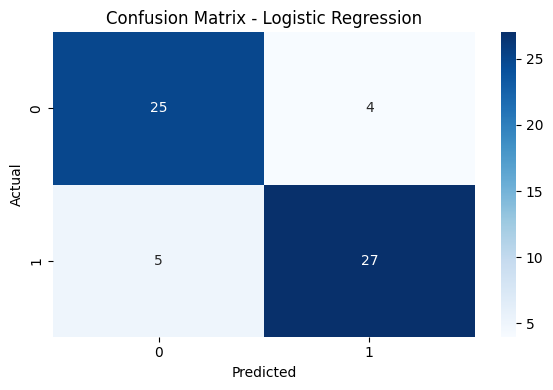

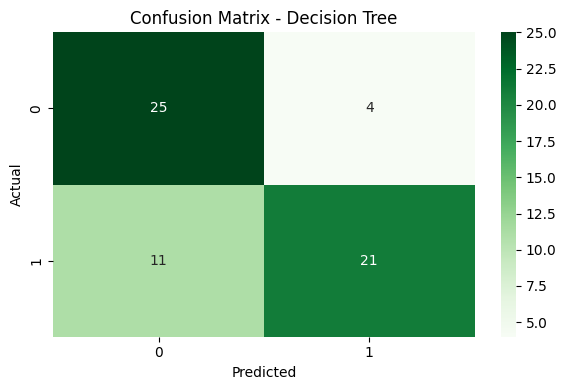

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --- Confusion Matrix - Decision Tree ---
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


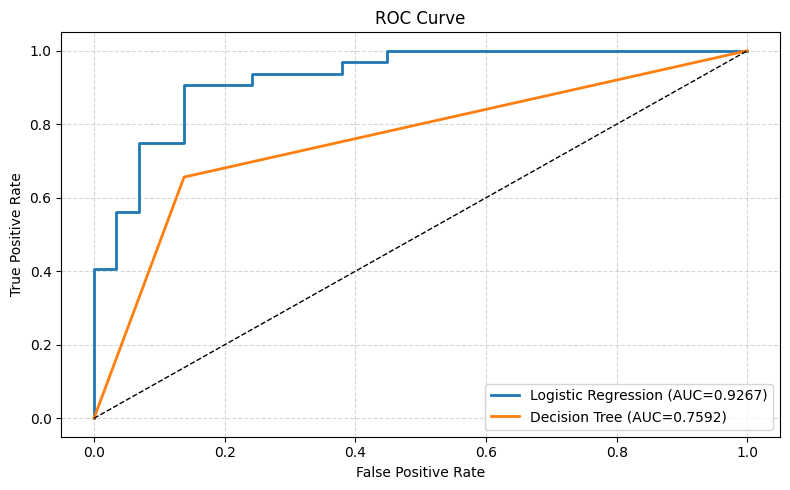

In [10]:
plt.figure(figsize=(8, 5))
for name, prob in [("Logistic Regression", lr_prob),
                   ("Decision Tree",       dt_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

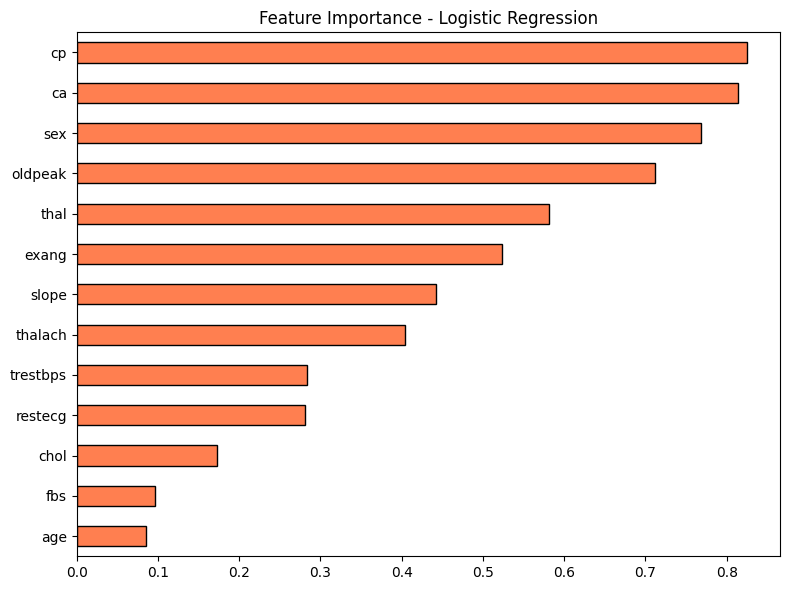


🎉 Task 3 Complete!


In [11]:
feat_imp = pd.Series(np.abs(lr.coef_[0]), index=df.drop(columns='target').columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 6),
                             color='coral', edgecolor='black')
plt.title('Feature Importance - Logistic Regression')
plt.tight_layout()
plt.show()

print("\n🎉 Task 3 Complete!")